### 1. Dependencies

In [467]:

import pandas as pd

import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy_design.univariate_sorting_preprocess import prepare_univariate_sorting_inputs, prepare_esg_universe_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe,get_japan_universe, get_processed_fx_rates, get_snp_esg_merge_to_universe, get_refinitive_snp_merge_to_universe, get_msci_esg_merge_to_universe, get_famafrench_factors, get_processed_index, get_accounting_data, get_gics_by_gvkey
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe, process_japan_universe, convert_factors_to_jpy
from functions.data_functions.ESG_coverage import build_esg_lookup, coverage_sample1_lc, coverage_sample2_returns, esg_coverage_table, firms_with_esg_data_by_year


In [468]:
#Important Filters
#############################################################

golden_data = "v_2C"

region_analysis = "North_America_and_Canada"


# Factor numeraire toggle (ONLY affects region_analysis == "Japan")
fama_factors_currency = "JPY"   # "USD" = US investor; "JPY" = Japanese investor
RF_JAPAN_PATH = "./data/FAMA/Rf_Japan_Monthly.xlsx"   # Japanese monthly T-bill (used when JPY)



# Signal Characterization
action_characterization = "original_matteo" #"dict_all_SDG_1D_prosperity_into_people, 4_stakeholder_new" # "original_matteo" # "Moji_5_signals", , dict_all_SDG_1D


start_year = 2018  # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#Univariate Sorting Percentile Split number
no_simple_quantiles = 6


ff_factors_number = 3

# ESG Variables
esg_choice = "none"
esg_full_universe = False   # ESG sort on the FULL Compustat universe (no LC merge): chosen ESG provider as the SOLE signal (set True + a provider esg_choice to run)
show_esg_corr_matricies = False   # show ESG vs behavioural regression tables (coef/SE/p)
esg_corr_method = "pearson"   # correlation matrix method: "pearson" | "spearman" | "kendall"
esg_min_group_size = 5   # drop (year, currency, GICS) groups with fewer than this many names
drop_real_estate_Full_ESG = True   # ESG-only: drop Real Estate before map_sectors (else folded into 'Financial')
drop_utilities_Full_ESG = True     # ESG-only: drop Utilities from the ESG universe
download_gics_data = False   # re-pull GICS from WRDS (False = read cached ./data/GICS/ csv)

signal_denominator = "Sum_All_Signals" #"Sum_All_Signals" #"Sum_All_Initiatives"


if esg_choice == "refinitiv":
    start_year = 2014 #USA this is 2015
    end_year = 2024

if esg_choice == "msci":
    start_year = 2015
    end_year = 2024

if esg_choice == "s&p":
    start_year = 2014
    end_year = 2022


##############################


# Other Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

add_accounting_data = False

industry_level = 0 # 0 = map to larger groups, 1 = GICS_level_1, 2 = GICS_level_2

japan_year_adjustment_split_month_for_two_or_one = 3

execute_3_filters = False
min_available_fyears = 3 #was 3
min_initatives_annual_reports = 5 #was 5
drop_suspicious_gvkeys = True

#Other Initalising variables Sector Analysis
drop_real_estate = True
drop_fin = False 
drop_utilities = False

drop_health_care = False
anlayse_fashion_only = False
# Keep below as weighted_average_score 
msci_score_column = "weighted"   # MSCI score column: "industry" (industry_adjusted_score) or "weighted" (weighted_average_score)


#sector split
top_x_by_industry_even_split = 6

#Filtering the GOLDEN data equally top and bottom
use_alpha_bound = True

show_sector_portfolio =  False
show_sample_portfolio = False
plot_coverage = False
show_esg_coverage = False   # gated ESG-coverage diagnostic at notebook end



# Long-short spread per signal. Key = signal to build a spread for; value = direction.
#   "high_minus_low" -> long top quantile (p_n), short bottom (p_1)
#   "low_minus_high" -> long bottom (p_1), short top (p_n)
# Works for any key in `signal_quantiles` (signal_0.. and, when esg_choice is set,
# esg_refinitive / esg_sp / esg_msci). Empty dict {} = no spreads.
hml_directions = {
    "signal_0": "high_minus_low",
    "signal_1": "high_minus_low",
    "signal_2": "high_minus_low"
}


In [ ]:
# --- Region-derived variables (MUST run AFTER papermill parameter injection) ---
# region_analysis (and fama_factors_currency) may be injected by the sweep AFTER the
# tagged parameters cell, so the currency_filter / fama_factor_region / convert_to_USD
# derivation lives here, not in cell 2, to pick up the injected region.
fama_factor_region = "Developed"
currency_filter = None
convert_to_USD = True


if region_analysis == "United_States":
    currency_filter = ['USD']
    region_filter = ["United States and Canada"]
    execute_region_filters = True
    convert_to_USD = False
    fama_factor_region = "United_States"
    



elif region_analysis == "North_America_and_Canada":
    currency_filter = ['USD'] 
    region_filter = ["United States and Canada"]
    execute_region_filters = True #If this is false there is rediculouly high alpha as it includes Irland and swiss
    convert_to_USD = False
    fama_factor_region = "North_America_and_Canada"
  


elif region_analysis == "Europe_and_North_America":
    #currencies we keep
    currency_filter = ['EUR', 'USD'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    
    


    

elif region_analysis == "Europe_and_North_America_and_Japan":
    #currencies we keep
    currency_filter = ['EUR', 'USD', 'JPY'] #['JPY'] #['CHF', 'GBP', 'EUR', 'USD'])]
    
    #check JPY currency conversion (Might need to invert it)
    
    #region_filter = ["Europe", "United States and Canada"]
    convert_to_USD = True
    fama_factor_region = "Developed"
    execute_region_filters = False
    


    

elif region_analysis == "Europe":
    currency_filter = ['EUR'] #"None" for uk
    region_filter = ["Europe"]
    execute_region_filters = True 
    #Keep in local currency
    #If we dont filter by EUR
    convert_to_USD = True    #True if UK
    fama_factor_region = "Europe"
  

elif region_analysis == "Japan":
    currency_filter = ['JPY'] 
    region_filter = ["Asia-Pacific"]
    execute_region_filters = True 
    #Keep portfolios in local currency (yen) when fama_factors_currency == "JPY" (Ei convert to USD is False)
    convert_to_USD = (fama_factors_currency == "USD")
    fama_factor_region = "Japan"


In [469]:
#Golden Dataset Location
from pathlib import Path
import os

golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)

# Golden Dataset
if golden_data == "v_2C":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2C_20260512.csv")
elif golden_data == "v_2B3":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B3_20260511.csv")
elif golden_data == "v_2A":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2A.csv")
elif golden_data == "v_2B1":
    lc = pd.read_csv(golden_location / "LC_dataset_v_2B1_20260409.csv")




# 1. Parameters 

In [470]:
# --- Parameter summary (prints below the cell) ---
from functions.output_paths import RUN_PARAM_NAMES, format_run_parameters

_run_parameters_text = format_run_parameters(globals(), RUN_PARAM_NAMES)
print(_run_parameters_text)


=== Run parameters ===
golden_data                  = 'v_2C'
region_analysis              = 'North_America_and_Canada'
action_characterization      = 'original_matteo'
signal_denominator           = 'Sum_All_Signals'
start_year                   = 2018
end_year                     = 2024
no_simple_quantiles          = 6
ff_factors_number            = 3
fama_factor_region           = 'North_America_and_Canada'
fama_factors_currency        = 'JPY'
RF_JAPAN_PATH                = './data/FAMA/Rf_Japan_Monthly.xlsx'
currency_filter              = ['USD']
convert_to_USD               = False
region_filter                = ['United States and Canada']
execute_region_filters       = True
esg_choice                   = 'none'
msci_score_column            = 'weighted'
esg_full_universe            = False
download_gics_data           = False
esg_min_group_size           = 5
drop_real_estate_Full_ESG    = True
drop_utilities_Full_ESG      = True
show_esg_corr_matricies      = False
esg_corr_metho

Signal Design

In [471]:
from functions.signal_design.signal_definitions import dict_all_SDG_1D, dict_2d_actions_stakeholders_original_matteo,dict_4_signals_Action_1D_Pre_Nikkei, dict_4_stakeholder_signals_Pre_Nikkei, dict_all_SDG_1D_prosperity_into_people

#Choose which action characterization to use, which is dependent on function

#categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()

if action_characterization == "original_matteo":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()

    #What signals to include~~~
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
}



elif action_characterization == "4_signals_new":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_signals_Action_1D_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }


elif action_characterization == "4_stakeholder_new":
    categories_dict, signal_0_name, signal_1_name, signal_2_name, signal_3_name = dict_4_stakeholder_signals_Pre_Nikkei()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
        "signal_3": signal_3_name,
    }


elif action_characterization == "dict_all_SDG_1D":
    categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_all_SDG_1D()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
        "signal_2": signal_2_name,
    }

elif action_characterization == "dict_all_SDG_1D_prosperity_into_people":
    categories_dict, signal_0_name, signal_1_name = dict_all_SDG_1D_prosperity_into_people()
    lc_signals = {
        "signal_0": signal_0_name,
        "signal_1": signal_1_name,
    }

if esg_full_universe:
    # ESG on the full Compustat universe: make the chosen ESG provider the sole signal.
    if esg_choice == "none":
        raise ValueError("esg_full_universe=True requires esg_choice in {'msci','refinitiv','s&p'} (not 'none').")
    lc_signals = {}
    show_sector_portfolio = False   # sector portfolio is pinned to signal_2, which will not exist
    hml_directions = {}             # cleared here; cell 11 re-adds the ESG long-short key


Signal Choice

### 2. Data

In [472]:

analyse_high_low = "High"
_bucket = "high" if analyse_high_low == "High" else "low"
_all_lc_signals = [(f"signal_{i}", _bucket) for i in range(len(lc_signals))]

if esg_choice == "none":

    universe_signals = {}
    analysis_selection = _all_lc_signals



elif esg_choice == "refinitiv":
    universe_signals = {"esg_refinitive": "esg_refinitive",}
    analysis_selection = _all_lc_signals + [("esg_refinitive", "high")]
    hml_directions["esg_refinitive"] = ["high_minus_low"]
    
elif esg_choice == "s&p":
    universe_signals = {    "esg_sp": "esg_sp",}
    analysis_selection = [("esg_sp", "high"), ("esg_sp", "low")] + _all_lc_signals
    hml_directions["esg_sp"] =  ["high_minus_low"]
elif esg_choice == "msci":
    universe_signals = {"esg_msci": "esg_msci",}
    analysis_selection = _all_lc_signals + [("esg_msci", "high")]
    hml_directions["esg_msci"] = ["high_minus_low"]


#### 2.1 LC dataset

clean below

In [473]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)

# raw LC snapshot (pre sample-filters) for the ESG-coverage diagnostic
if show_esg_coverage:
    lc_raw_for_coverage = lc.copy()




# Additional Filters!



if execute_3_filters:
    #1-------------Filter companies with less than 3 years of data


    from functions.data_functions.process_lc import add_available_fyears
    lc = add_available_fyears(lc)

    print(f"Before filtering companies with less than {min_available_fyears} years of data: ", lc.shape)
    lc = lc[lc["n_available_fyears"] >= min_available_fyears]
    print(f"After filtering companies with less than {min_available_fyears} years of data: ", lc.shape)



    #2-------------Filter out suspicious gvkeys

    if drop_suspicious_gvkeys:
        print("Shape before: ", lc.shape)

        lc_suspicious = pd.read_csv(golden_location / "lc_gvkey_suspicious.csv")

        print("Number of suspicious: ", lc_suspicious.shape[0])
        print(lc_suspicious["suspicious_flag"].value_counts())

        lc_suspicious["original_gvkey"] = lc_suspicious["original_gvkey"].astype(str).str.zfill(6)
        lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)
        print("Number of suspicious that are NAN: ", lc_suspicious["suspicious_flag"].isna().sum())

        print("unique gvkeys: ", lc["gvkey"].nunique(), "Unique gvkeys in suspicious: ", lc_suspicious["original_gvkey"].nunique())
        lc = lc.merge(lc_suspicious[["original_gvkey", "suspicious_flag", "likely_reason_codes"]], left_on="gvkey", right_on="original_gvkey", how="left")
        print(lc["suspicious_flag"].value_counts())
        print("Number of suspicious that are NAN: ", lc["suspicious_flag"].isna().sum())
        lc.to_csv("./data/debug/lc_before_suspicious_filtered.csv")
        lc = lc[lc["suspicious_flag"] != True]
        print("Shape after filtering Truly Sus: ", lc.shape)


    #3-------------Filter out Annual Reports with Less tha 5 Total initaitves
    print("Before filtering Annual Reports: ", lc.shape)
    lc = lc[~((lc["n_predicted_initiatives"] < min_initatives_annual_reports) & (lc["report_type"] == "Annual Report"))]
    print("After filtering Annual Reports: ", lc.shape)



    lc.to_csv("./data/debug/lc_after_all_filter.csv")



if anlayse_fashion_only:
    lc = lc[lc['GICS_level_3'].isin(["Textiles, Apparel & Luxury Goods"])]



if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']




>>>> add_missing_gvkeys: filled 0 rows
Added SREC columns:  Index(['customers', 'employees', 'environment',
       'local communities and society', 'nothing', 'shareholders',
       'suppliers'],
      dtype='object')


In [474]:


if industry_level == 0:
    lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
elif industry_level == 1:
    lc['Industry'] = lc['GICS_level_1']
elif industry_level == 2:
    lc['Industry'] = lc['GICS_level_2']


if drop_fin:
    lc = lc[lc['Industry'] != 'Financial']

if drop_utilities:
    lc = lc[lc['Industry'] != 'Utilities']

if drop_health_care:
    lc = lc[lc['Industry'] != 'Health Care']

# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


if execute_region_filters == True:
    lc = lc[lc["MacroRegion"].isin(region_filter)]
    if region_analysis == "United_States":
            lc = lc[lc["loc"] == "USA"]


In [475]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]

    else:
        lc[f'sum_with_{value}'] = lc[key].values



if signal_denominator == "Sum_All_Signals":
    lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)
elif signal_denominator == "Sum_All_Initiatives":
    lc['sum_activities'] = lc['n_predicted_initiatives']


In [476]:
lc["sum_activities"].describe()

count    11012.000000
mean        26.540774
std         27.545424
min          0.000000
25%          8.000000
50%         19.000000
75%         36.000000
max        612.000000
Name: sum_activities, dtype: float64

In [477]:
if use_alpha_bound:

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (alpha_bound/2),
        upper_exclude= (alpha_bound/2),
    )

else:
    lower_exclude = 0.2*2
    upper_exclude = 0.05*2

    lc = filter_sum_activities_by_fiscal_year_quantiles(
        lc,
        lower_exclude= (lower_exclude/2),
        upper_exclude= (upper_exclude/2),
    )

In [478]:
lc["sum_activities"].describe()

count    9728.000000
mean       23.678146
std        17.476149
min         3.000000
25%         9.000000
50%        19.000000
75%        34.000000
max        80.000000
Name: sum_activities, dtype: float64

Create the signal

In [479]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [480]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

2526

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4 - Japan

5 - ESG

4- Fama-French

5- Global Universe

6- Accounting Data

In [481]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)

# Keep local-currency series for Europe/Japan analysis (no FX conversion)

usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)

usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year, end_year, download_wrds_data=False)
row_universe = process_row_universe(row_universe,fx_rates,convert_to_USD,)


japan_universe = get_japan_universe(start_year, end_year, download_wrds_data=False)
japan_universe = process_japan_universe(japan_universe,fx_rates,convert_to_USD,japan_year_adjustment_split_month_for_two_or_one)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100
    japan_universe['esg'] = 100

elif esg_choice != 'none':
    if esg_choice == "refinitiv":
        usa_universe, row_universe, japan_universe = get_refinitive_snp_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "s&p":
        usa_universe, row_universe, japan_universe = get_snp_esg_merge_to_universe(usa_universe, row_universe, japan_universe)
    elif esg_choice == "msci":
        usa_universe, row_universe, japan_universe = get_msci_esg_merge_to_universe(usa_universe, row_universe, japan_universe, score_column=msci_score_column)


print("usa_universe unique gvkeys:", usa_universe["gvkey"].nunique())
print("row_universe unique gvkeys:", row_universe["gvkey"].nunique())
print("japan_universe unique gvkeys:", japan_universe["gvkey"].nunique())
fama_french = get_famafrench_factors(
    start_year,
    end_year,
    fama_factor_region,
    ff_factors_number,
    download_developed_ff_data=False,
)

# Convert USD factors -> JPY numeraire for the Japanese-investor case
if region_analysis == "Japan" and fama_factors_currency == "JPY":
    fama_french = convert_factors_to_jpy(fama_french, fx_rates, RF_JAPAN_PATH)

global_universe = process_global_universe(usa_universe,row_universe,japan_universe,currency_filter,mktcap_covered,
    esg_choice,)

print("columns with year")
print([c for c in global_universe.columns if c == 'year' or c.startswith('year_')])

# if add_accounting_data:
#     #Note this will result in a lower sample and non-profitable stocks will be removed
#     global_universe = global_universe.drop(columns=['year_x'], errors='ignore')
#     global_universe = get_accounting_data(global_universe, region_analysis, start_year, end_year, dowload_acc_data = True)


#Ensure gvkey is 6 digits for merging
global_universe["gvkey"] = global_universe["gvkey"].astype(str).str.zfill(6)
lc["gvkey"] = lc["gvkey"].astype(str).str.zfill(6)


print("global_universe unique gvkeys:", global_universe["gvkey"].nunique())

usa_universe unique gvkeys: 2412
row_universe unique gvkeys: 4022
japan_universe unique gvkeys: 3812
columns with year
['year']
global_universe unique gvkeys: 1074


In [482]:
lc["Industry"].unique()

array(['Consumer', 'Financial', 'ICT', 'Primary Industries',
       'Industrials', 'Health Care', 'Utilities'], dtype=object)

### 3. Univariate Portfolio sorting

In [483]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']

if esg_full_universe:
    # Level 2: ESG on the FULL Compustat universe (no LC merge). GICS supplies the
    # industry classification for industry-neutral standardization.
    gics_by_gvkey = get_gics_by_gvkey(
        global_universe, region_analysis, end_year, download_gics_data=download_gics_data
    )
    prep = prepare_esg_universe_sorting_inputs(
        global_universe=global_universe,
        gics_by_gvkey=gics_by_gvkey,
        fama_french=fama_french,
        universe_signals=universe_signals,
        industry_level=industry_level,
        year_col="last_year",
        min_group_size=esg_min_group_size,
        drop_real_estate=drop_real_estate_Full_ESG,
        drop_utilities=drop_utilities_Full_ESG,
    )
else:
    prep = prepare_univariate_sorting_inputs(
        global_universe=global_universe,
        lc=lc,
        fama_french=fama_french,
        lc_signals=lc_signals,
        universe_signals=universe_signals,
        category_columns=sorted(categories_dict.keys()),
        cols_standardization=cols_standardization,
        apply_geo_filter=False,
        show_corr_matrices=show_esg_corr_matricies,
        corr_method=esg_corr_method,
    )

global_universe = prep.global_universe
global_returns  = prep.global_returns
signals         = prep.signals        # dict: column name -> (date x gvkey_iid) pivot
signal_names    = prep.signal_names   # dict: column name -> display name
signal_df       = prep.global_long_df
fama_french     = prep.fama_french


[prepare_univariate_sorting_inputs] FF rows=66 | returns rows=66
[prepare_univariate_sorting_inputs] all months match: True
    ff_date returns_date  match
0   2019-07      2019-07   True
1   2019-08      2019-08   True
2   2019-09      2019-09   True
3   2019-10      2019-10   True
4   2019-11      2019-11   True
5   2019-12      2019-12   True
6   2020-01      2020-01   True
7   2020-02      2020-02   True
8   2020-03      2020-03   True
9   2020-04      2020-04   True
10  2020-05      2020-05   True
11  2020-06      2020-06   True
12  2020-07      2020-07   True
13  2020-08      2020-08   True
14  2020-09      2020-09   True
15  2020-10      2020-10   True
16  2020-11      2020-11   True
17  2020-12      2020-12   True
18  2021-01      2021-01   True
19  2021-02      2021-02   True
20  2021-03      2021-03   True
21  2021-04      2021-04   True
22  2021-05      2021-05   True
23  2021-06      2021-06   True
24  2021-07      2021-07   True
25  2021-08      2021-08   True
26  2021-09 

# code to filter infinte stocks

In [484]:
# FIND ANY STOCKS THAT HAVE INF VALUES  

import numpy as np

bad_columns = set()
for df in signals.values():
    # numeric only, in case of odd dtypes
    num = df.select_dtypes(include=[np.number])
    if num.empty:
        continue
    bad_columns.update(num.columns[np.isinf(num).any(axis=0)].tolist())

bad_columns = list(bad_columns)

print("gvekys dropped due to inf values:")
print(bad_columns)


# filter these infinite values

signals = {
    name: df.drop(columns=bad_columns, errors="ignore")
    for name, df in signals.items()
}

import numpy as np
if 'signal_0' in signals:
    fit1 = signals['signal_0'].select_dtypes(include=["float", "float64"])
    if np.isinf(fit1).sum().sum() > 0:
        print("There are inf values in the signal_0 column")

gvekys dropped due to inf values:
[]


% Nan in accounting data

In [485]:
# if add_accounting_data:
#     #Amount of missing accounting data as a percent
#     cols = ["roa0","roa1","roa2","ros0","ros1","ros2","sales_intensity"]
#     print((100 * global_universe[cols].isna().mean()).sort_values(ascending=False))

In [486]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [487]:
from functions.portfolio_strategy_design.Univariate_Portfolio import UnivariateQuantilePortfolio

signal_quantiles: dict[str, pd.DataFrame] = {}
signal_quantile_constituents: dict[str, pd.Series] = {}

for col, pivot in signals.items():
    U = UnivariateQuantilePortfolio(
        signal=pivot,
        returns=global_returns,
        n_quantiles=no_simple_quantiles,
        first_conditioning_set=first_conditioning_set,
        take_extremes=take_extremes,
        n_extremes_quantiles=no_simple_extremes_quantiles,
    )
    signal_quantiles[col] = U.compute_returns()
    signal_quantile_constituents[col] = U.get_constituents_over_time()

# 4. Sector Split

In [488]:
# Store constituents over time + compute “next-month return” by Industry


from functions.portfolio_strategy_design.Sector_Portfolio import SectorPortfolio


if show_sector_portfolio:
    # Sector portfolio is pinned to signal_2.
    global_signal_2 = signals["signal_2"]

    #Build an industry pivot aligned to global_returns  and global_signal_*
    global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

    #This will automatically split the even_split_no stocks into the unique sectors.
    #Select the n highest ranked stocks in each industruy and build portfolios using them.
    S = SectorPortfolio(
        signal=global_signal_2,
        returns=global_returns,
        global_universe=global_universe,
        sector_split=top_x_by_industry_even_split,          # fixed N per industry
        manual_input_split=False,
        first_conditioning_set=first_conditioning_set,
        ascending=False,
    )


    #all_industry_returns = S.compute_industry_returns()
    industry_constituents = S.get_constituents_over_time()   

    #Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
    sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


In [489]:
# Add Market Portfolios
market_factor = fama_french["mktrf"]

file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, global_returns) 

In [490]:
# Transform in excess returns using the risk free rate

for col in signal_quantiles:
    signal_quantiles[col] = signal_quantiles[col].sub(fama_french['rf'].values, axis=0)

MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)

if show_sector_portfolio:
    sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)


Excess_returns_sample = (
    global_returns.mean(axis=1)
    .sub(fama_french["rf"].values, axis=0)
    .to_frame("Sample")
)

#no need for market_factor


In [491]:
# Regression inputs keep their NaN first row (ff3_regressions drops it).
# Zeroed copies are ONLY for cumulative plots / compounding.
global_returns_cum = set_first_row_to_zero(global_returns)
signal_quantiles_cum = {c: set_first_row_to_zero(df) for c, df in signal_quantiles.items()}

market_factor_cum = market_factor.copy()   # .copy() avoids mutating fama_french["mktrf"]
market_factor_cum.iloc[0] = 0

if show_sector_portfolio:
    sector_portfolio_returns_cum = sector_portfolio_returns.copy()
    sector_portfolio_returns_cum.iloc[0] = 0

# 5. Fama-French

In [492]:

if show_sector_portfolio:
    sector_portfolio_returns_df = pd.DataFrame()
    sector_portfolio_returns_df[f"Sector equal split {signal_2_name}"] = sector_portfolio_returns
    sector_portfolio_returns = sector_portfolio_returns_df

High - Low

In [493]:
# Per-signal long-short spreads, driven by `hml_directions` (set in the parameters cell).
# Build two parallel dicts keyed by the generated spread label:
#   spread_signals[label] -> raw spread (NaN first row) for FF tables + rolling FF regression
#   spread_cum[label]     -> zeroed-first-row spread for cumulative compounding/plot
# Long-short spread: rf cancels ((high-rf) - (low-rf) = high - low), so rf is NOT added back.
_hml_hi, _hml_lo = f"p_{no_simple_quantiles}", "p_1"

spread_signals: dict[str, pd.DataFrame] = {}
spread_cum: dict[str, pd.Series] = {}

for _sig, _dirs in hml_directions.items():
    if _sig not in signal_quantiles:
        raise KeyError(
            f"{_sig!r} in hml_directions not found in signal_quantiles "
            f"(available: {list(signal_quantiles)})"
        )

    # A signal may map to a single direction (str) or several (list/tuple),
    # e.g. ["high_minus_low", "low_minus_high"] to build both spreads.
    for _dir in ([_dirs] if isinstance(_dirs, str) else _dirs):
        if _dir == "high_minus_low":
            _label = f"High - Low {signal_names[_sig]}"
            _raw = signal_quantiles[_sig][_hml_hi] - signal_quantiles[_sig][_hml_lo]
            _cum = signal_quantiles_cum[_sig][_hml_hi] - signal_quantiles_cum[_sig][_hml_lo]
        elif _dir == "low_minus_high":
            _label = f"Low - High {signal_names[_sig]}"
            _raw = signal_quantiles[_sig][_hml_lo] - signal_quantiles[_sig][_hml_hi]
            _cum = signal_quantiles_cum[_sig][_hml_lo] - signal_quantiles_cum[_sig][_hml_hi]
        else:
            raise ValueError(
                f"Unknown direction {_dir!r} for {_sig}; use 'high_minus_low' or 'low_minus_high'"
            )

        spread_signals[_label] = _raw.to_frame(_label)
        spread_cum[_label] = _cum


In [494]:
#### Rolling Alpha
from functions.portfolio_metrics.fama_french import rolling_ff_alphas

# Select what you want to analyse in the rolling alpha and cumulative returns
base_analysis_selection = [(s, "high") for s in reversed(lc_signals)]
if not esg_full_universe:
    base_analysis_selection.append(("signal_0", "low"))
# base_analysis_selection.append(("signal_2", "high"))


# base_analysis_selection.remove(("signal_0", "high"))


if show_sector_portfolio:
    base_analysis_selection.append(("Sector equal split signal_2", "high"))




if esg_choice == "refinitiv":
   
    base_analysis_selection.append(("esg_refinitive", "high"))
elif esg_choice == "s&p":
    base_analysis_selection.append(("esg_sp", "high"))
elif esg_choice == "msci":
    base_analysis_selection.append(("esg_msci", "high"))
    


rolling_alpha_selection = base_analysis_selection

_valid_buckets = {"high", "low"}
_invalid_buckets = sorted({b for _, b in rolling_alpha_selection} - _valid_buckets)
if _invalid_buckets:
    raise ValueError(f"Invalid bucket(s) in analysis_selection: {_invalid_buckets}. Use 'high' or 'low'.")

_missing_signal_keys = sorted({c for c, _ in rolling_alpha_selection} - set(signal_quantiles))
if _missing_signal_keys:
    raise KeyError(f"Signal key(s) in analysis_selection not found in signal_quantiles: {_missing_signal_keys}")

_bucket_to_col    = {"high": f"p_{no_simple_quantiles}", "low": "p_1"}
_bucket_to_prefix = {"high": "High", "low": "Low"}

rolling_signals_arg = [
    {
        "label": f"{_bucket_to_prefix[bucket]} {signal_names[col]}",
        "returns": signal_quantiles[col],
        "alpha_column": _bucket_to_col[bucket],
    }
    for col, bucket in rolling_alpha_selection
]


if show_sector_portfolio:
    _sector_label = f"Sector equal split {signal_2_name}"
    rolling_signals_arg.append({
        "label": _sector_label,
        "returns": sector_portfolio_returns,
        "alpha_column": _sector_label,
    })

if show_sample_portfolio:
    _market_sample_label = f"Sample"
    rolling_signals_arg.append({
        "label": _market_sample_label,
        "returns": Excess_returns_sample,
        "alpha_column": _market_sample_label,
    })


for _label, _df in spread_signals.items():
    rolling_signals_arg.append({
        "label": _label,
        "returns": _df,
        "alpha_column": _label,
    })


try:
    rolling_alphas_window_size_40 = rolling_ff_alphas(
        signals=rolling_signals_arg,
        fama_french=fama_french,
        window_size=40,
        n_factors=ff_factors_number,
    )
except Exception as e:
    print(f"Error in rolling_ff_alphas: {e}")


rolling_alphas_window_size_24 = rolling_ff_alphas(
    signals=rolling_signals_arg,
    fama_french=fama_french,
    window_size=24,
    n_factors=ff_factors_number,
)




# 6. Performance Metrics

In [495]:
global_gross_portfolio_returns = pd.DataFrame(index=global_returns_cum.index)
if show_sample_portfolio:
    global_gross_portfolio_returns['Sample'] = 1 + global_returns_cum.mean(axis=1).sub(fama_french["rf"].values, axis=0)


global_gross_portfolio_returns["Market"] = 1 + market_factor_cum 
# Single selection shared with rolling alpha.
portfolio_selection = base_analysis_selection

for col, bucket in portfolio_selection:
    quantile_col = _bucket_to_col[bucket]
    label        = f"{_bucket_to_prefix[bucket]} {signal_names[col]}"
    global_gross_portfolio_returns[label] = 1 + signal_quantiles_cum[col][quantile_col]


if show_sector_portfolio:
    _sector_col = f"Sector equal split {signal_2_name}"
    global_gross_portfolio_returns[_sector_col] = 1 + sector_portfolio_returns_cum[_sector_col]

#global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns

# Add risk free rate back for cumulative returns
non_risk_free_returns = global_gross_portfolio_returns.add(fama_french["rf"].values, axis=0)
portfolio_returns = non_risk_free_returns - 1

# Long-short spreads: rf cancels out ((high-rf) - (low-rf) = high - low),
# so append directly without adding rf back.
for _label, _series in spread_cum.items():
    portfolio_returns[_label] = _series

# Cumulative Returns Plot

In [496]:
portfolio_returns.isna().sum()

Market                       0
High transformation          0
High preparation             0
High advocacy                0
Low advocacy                 0
High - Low advocacy          0
High - Low preparation       0
High - Low transformation    0
dtype: int64

In [497]:
from functions.portfolio_metrics.fama_french import ff3_regressions, ff5_regressions, rolling_ff_alphas

# FF3 table: every signal plus the sector portfolio.
ff3_parts = [
    low_high(
        ff3_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
        signal_names[col],
    )
    for col in signal_quantiles
]

take_high_minus_low = True
if take_high_minus_low:
    for _label, _df in spread_signals.items():
        ff3_parts.append(ff3_regressions(_df, fama_french.reset_index(drop=True)))

if show_sector_portfolio:
    ff3_parts.append(ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

if show_sample_portfolio:
    ff3_parts.append(ff3_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + _{start_date}-{end_date} + '.csv')
ff3_parts_df.head()

,Low advocacy,High advocacy,Low preparation,High preparation,Low transformation,High transformation,High - Low advocacy,High - Low preparation,High - Low transformation
alpha,0.07,-0.07,0.02,-0.05,0.08,0.22,-0.14,-0.07,0.14
beta_mkt,1.00,1.06,1.00,1.05,1.04,0.98,0.07,0.05,-0.06
beta_smb,0.13,0.27,0.22,0.18,0.21,0.18,0.15,-0.03,-0.03
beta_hml,0.30,0.35,0.30,0.31,0.30,0.24,0.04,0.01,-0.06
p-value(alpha),0.63,0.62,0.89,0.75,0.60,0.17,0.39,0.59,0.38


In [498]:
# FF5 table: mirror of the FF3 cell above. Guarded on rmw/cma so ff_factors_number=3
# (no FF5 factors) interactive runs don't break; ff_factors_number=5 sweeps still compute it.
if {"rmw", "cma"}.issubset(fama_french.columns):
    ff5_parts = [
        low_high(
            ff5_regressions(signal_quantiles[col], fama_french.reset_index(drop=True)),
            signal_names[col],
        )
        for col in signal_quantiles
    ]

    take_high_minus_low = True
    if take_high_minus_low:
        for _label, _df in spread_signals.items():
            ff5_parts.append(ff5_regressions(_df, fama_french.reset_index(drop=True)))

    if show_sector_portfolio:
        ff5_parts.append(ff5_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True)))

    if show_sample_portfolio:
        ff5_parts.append(ff5_regressions(Excess_returns_sample, fama_french.reset_index(drop=True)))

    ff5_parts_df = pd.concat(ff5_parts, axis=1).round(2)
    ff5_parts_df.head()
else:
    print("[FF5] rmw/cma not in fama_french (ff_factors_number != 5) -> skipping FF5 table")


In [499]:
# --- Sweep harness: persist FF tables when running under papermill ---
# No-op during normal interactive runs (sweep_mode defaults to False).
if globals().get("sweep_mode", False):
    import os, pickle
    _sweep_out = globals().get("sweep_out_dir", "./output/SWEEP")
    os.makedirs(_sweep_out, exist_ok=True)
    _rid = str(globals().get("sweep_run_id", "run"))
    _payload = {"ff3": ff3_parts_df, "ff5": ff5_parts_df}
    _fp = os.path.join(_sweep_out, f"ff_{_rid}.pkl")
    with open(_fp, "wb") as _f:
        pickle.dump(_payload, _f)
    print(f"[sweep] saved FF tables for run {_rid} -> {_fp}")


Saving run artifacts to: output/original_matteo/North_America_and_Canada/Sum_All_Signals/no_esg/no_filters/2019-07-2024-12_split6


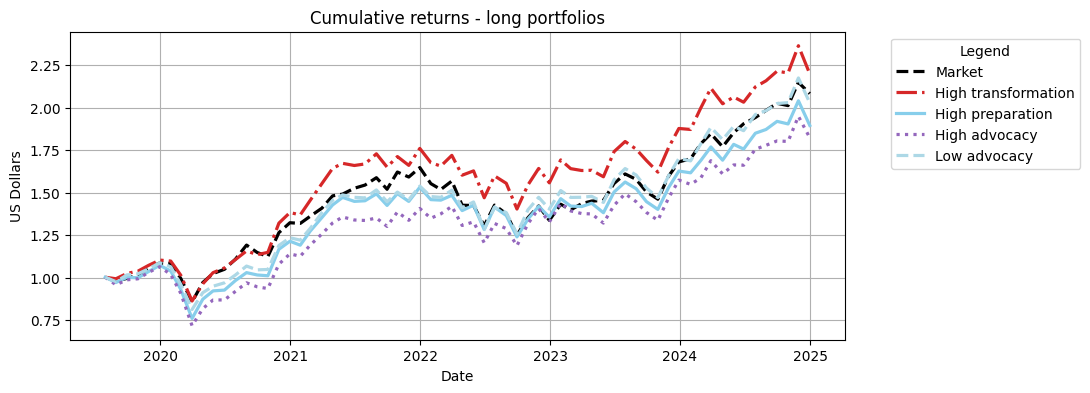

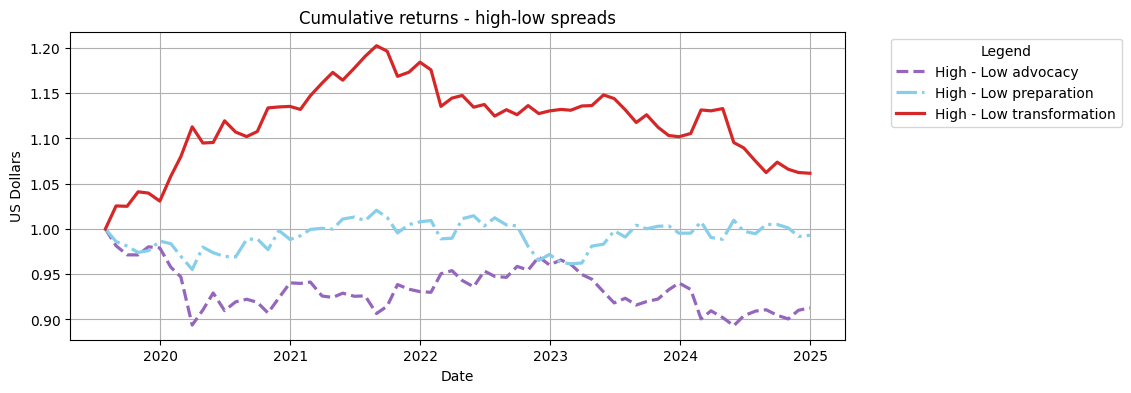

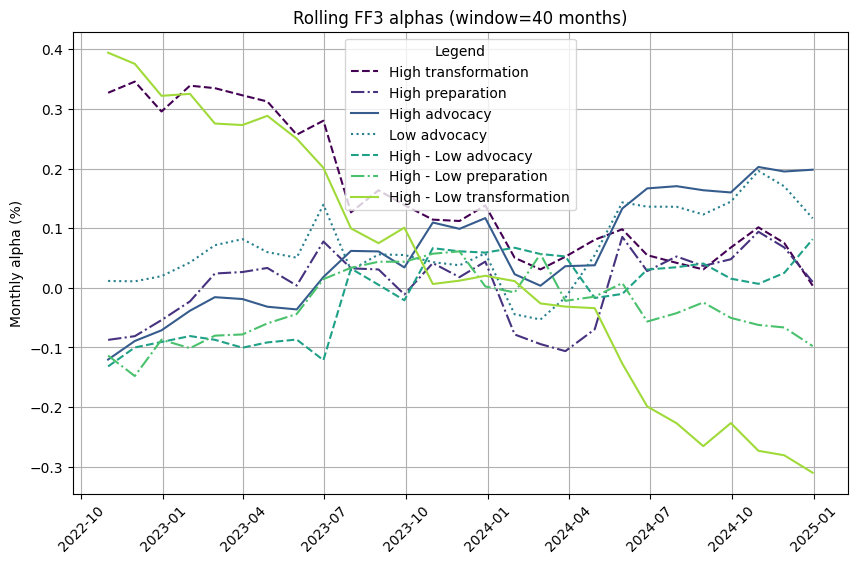

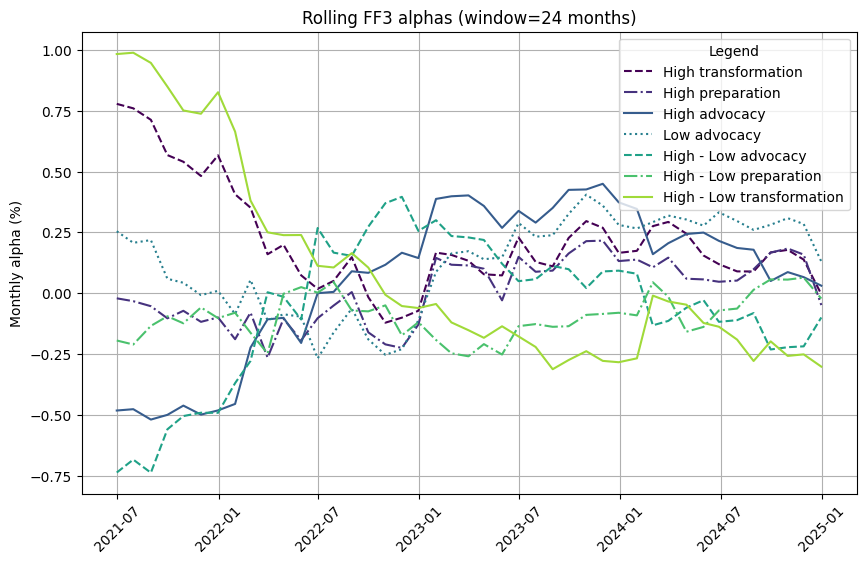

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-3.08%,2.82%,23.92%,23.92%,26.43%,91.86%,108.31%,108.31%
High transformation,-7.03%,-0.75%,17.09%,17.09%,24.90%,99.33%,119.85%,119.85%
High preparation,-7.12%,-1.26%,16.50%,16.50%,23.75%,76.82%,89.54%,89.54%
High advocacy,-6.48%,1.02%,15.83%,15.83%,29.58%,71.32%,82.29%,82.29%
Low advocacy,-6.77%,0.17%,19.19%,19.19%,31.81%,86.51%,102.78%,102.78%
High - Low advocacy,0.29%,0.90%,-2.93%,-2.93%,-1.93%,-6.76%,-8.72%,-8.72%
High - Low preparation,0.13%,-1.18%,-0.23%,-0.23%,-1.47%,0.65%,-0.70%,-0.70%
High - Low transformation,-0.08%,-1.14%,-3.66%,-3.66%,-10.36%,2.98%,6.15%,6.15%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.83,-10.81%,-24.13%,,
High transformation,0.84,-11.59%,-21.86%,0.22,0.170
High preparation,0.67,-13.19%,-29.19%,-0.05,0.750
High advocacy,0.62,-14.39%,-32.67%,-0.07,0.620
Low advocacy,0.76,-12.66%,-25.31%,0.07,0.630
High - Low advocacy,-0.32,-4.23%,-10.69%,-0.14,0.390
High - Low preparation,-0.02,-2.09%,-5.79%,-0.07,0.590
High - Low transformation,0.27,-3.35%,-11.72%,0.14,0.380


In [500]:
import importlib
import functions.output_paths as output_paths_module
importlib.reload(output_paths_module)

from functions.portfolio_metrics.Strategy_Perfomance import StrategyPerformance, aligned_cumulative_colors
from functions.portfolio_metrics.fama_french import plot_rolling_alpha_function
from functions.output_paths import (
    output_csv_dir,
    output_images_dir,
    output_images_other_dir,
    output_run_dir,
    save_run_parameters,
)


start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

_run_dir = output_run_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_csv_dir = output_csv_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_img_dir = output_images_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
_other_img_dir = output_images_other_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)
print(f"Saving run artifacts to: {_run_dir}")

save_run_parameters(_run_dir / "parameters.txt", globals())

ff_parts_df = ff3_parts_df if ff_factors_number == 3 else ff5_parts_df

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff_parts_df)

_ff = fama_factor_region

_csv_dir.mkdir(parents=True, exist_ok=True)
ff_parts_df.to_csv(_csv_dir / f"ff{ff_factors_number}_regressions_ff-{_ff}.csv")

cumulative_table = sp.cumulative_performance_table(
    csv_path=_csv_dir / f"strategy_cumulative_performance_ff-{_ff}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=_csv_dir / f"strategy_performance_metrics_ff-{_ff}.csv")

# Two separate cumulative-returns plots. The long-short (High - Low / Low - High)
# spreads stay in `sp.portfolio_returns`, so the cumulative table, risk table,
# regressions and rolling alphas are unaffected by how we split the plots.
_spread_cols = [c for c in spread_cum if c in portfolio_returns.columns]

# (1) Long portfolios only (spreads dropped); keeps Market / Sample benchmarks.
_long_only = portfolio_returns.drop(columns=_spread_cols, errors="ignore")
# Shared colours: each high-low spread matches its "High <signal>" line in the long plot.
_long_colors, _spread_colors = aligned_cumulative_colors(_long_only.columns, _spread_cols)
sp.plot_cumulative_returns(
    portfolio_returns=_long_only,
    colors=_long_colors,
    title="Cumulative returns - long portfolios",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=_img_dir / f"cumulative_returns_long_ff-{_ff}.png",
    csv_path=_csv_dir / f"gross_cumulative_returns_long_ff-{_ff}.csv",
)

# (2) High-low spreads only -- drawn only when at least one high-low signal exists.
if _spread_cols:
    sp.plot_cumulative_returns(
        portfolio_returns=portfolio_returns[_spread_cols],
        colors=_spread_colors,
        title="Cumulative returns - high-low spreads",
        tight_layout_rect = (0, 5, 100, 0.9),
        save_path=_img_dir / f"cumulative_returns_highlow_ff-{_ff}.png",
        csv_path=_csv_dir / f"gross_cumulative_returns_highlow_ff-{_ff}.csv",
    )
else:
    print("[plot] no high-low spreads (hml_directions empty) -> skipping spread plot")


# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
try:
    plot_rolling_alpha_function(
        rolling_alphas_window_size_40,
        title=f"Rolling FF{ff_factors_number} alphas (window={40} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{40}.csv",
)
except Exception as e:
    print(f"Error in plot_rolling_alpha_function: {e}")

plot_rolling_alpha_function(
    rolling_alphas_window_size_24,
    title=f"Rolling FF{ff_factors_number} alphas (window={24} months)",
    save_path=_img_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.png",
    csv_path=_csv_dir / f"rolling_alphas_ff{ff_factors_number}_w{24}.csv",
)

display(cumulative_table)
display(risk_table)

# sp.plot_rolling_sharpe(window=40, save_path=_other_img_dir / f"strategy_rolling_sharpe_40m_ff-{_ff}.png")
#sp.plot_rolling_sharpe(window=60, save_path=_other_img_dir / f"strategy_rolling_sharpe_60m_ff-{_ff}.png")
# sp.plot_rolling_sharpe(window=24, save_path=_other_img_dir / f"strategy_rolling_sharpe_24m_ff-{_ff}.png")

In [501]:
# --- ESG vs behavioural signals: standardised AND non-standardised (regression + correlation) ---
# LC path only. Reads already-computed signal_df (standardised) + global_universe (raw 0-1 ESG + raw shares).
# Only the chosen esg_choice provider. Files are saved with the scale + ESG provider in the name.
from functions.portfolio_metrics.signal_correlation import (
    esg_signal_relationship_outputs, masked_raw_value_df,
)

if show_esg_corr_matricies and esg_choice != "none" and not esg_full_universe:
    # standardised (z-scored signals)
    esg_signal_relationship_outputs(
        signal_df, signal_names, _img_dir, _csv_dir,
        method=esg_corr_method, scale_tag="standardised", show=True,
    )
    # non-standardised (raw values on the same masked firm-months)
    # non-standardised is already DISPLAYED mid-pipeline (before normalisation); here we only SAVE it.
    _non_norm_df = masked_raw_value_df(global_universe, signal_df, signal_names)
    esg_signal_relationship_outputs(
        _non_norm_df, signal_names, _img_dir, _csv_dir,
        method=esg_corr_method, scale_tag="non_standardised", show=False,
    )


In [502]:
from functions.extra_functions.code_done_sound_effect import play_done_sound

play_done_sound()

# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


The following only inspects the high transformation

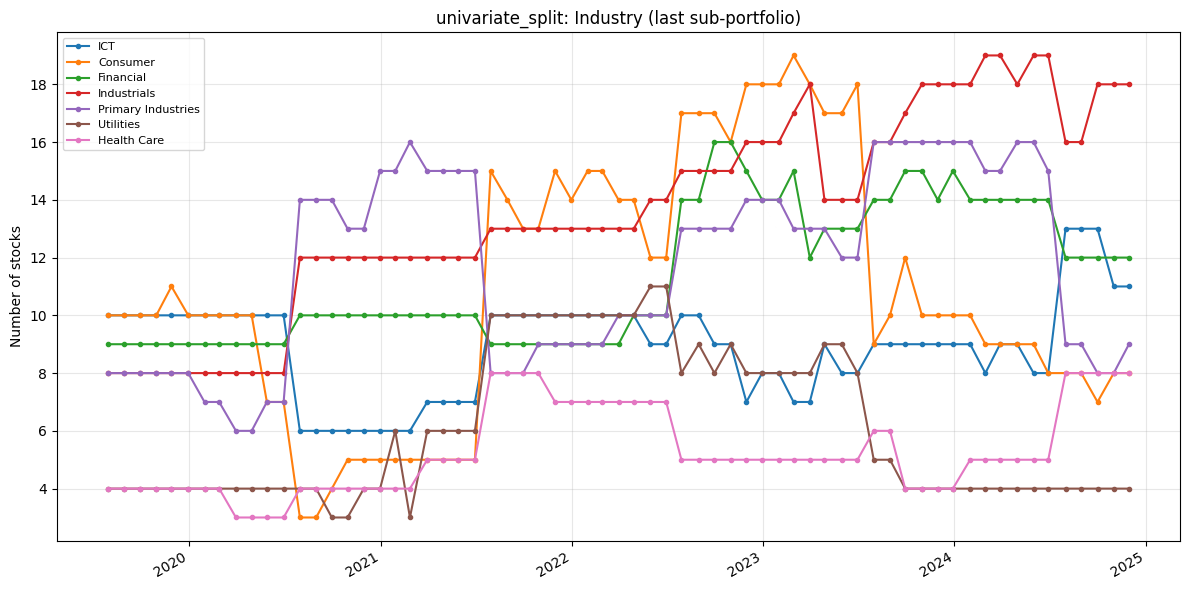

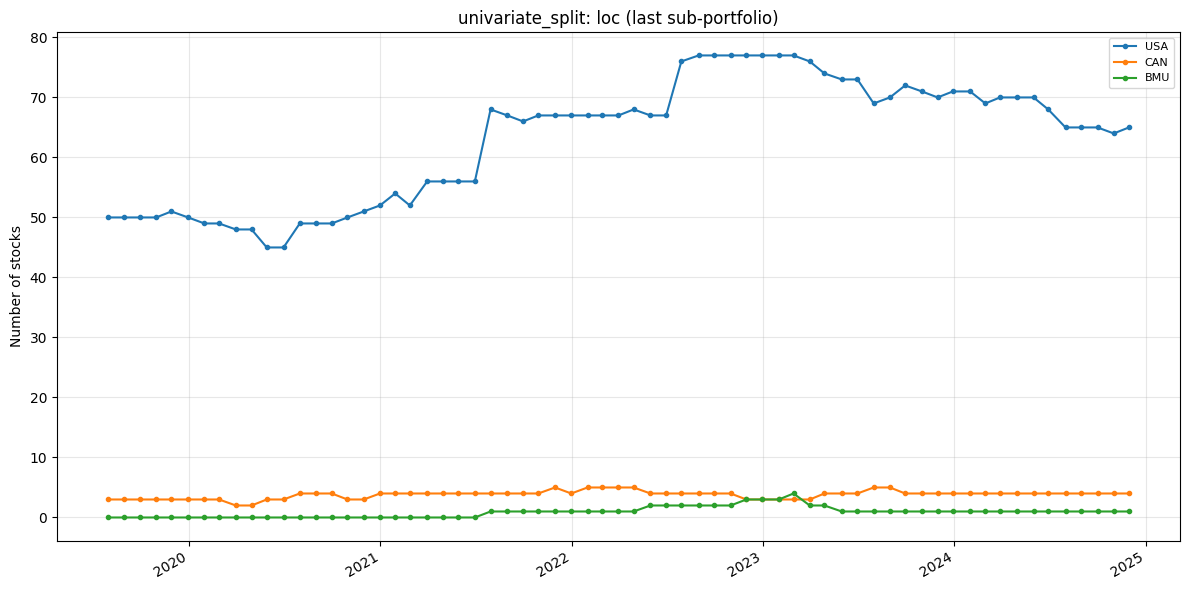

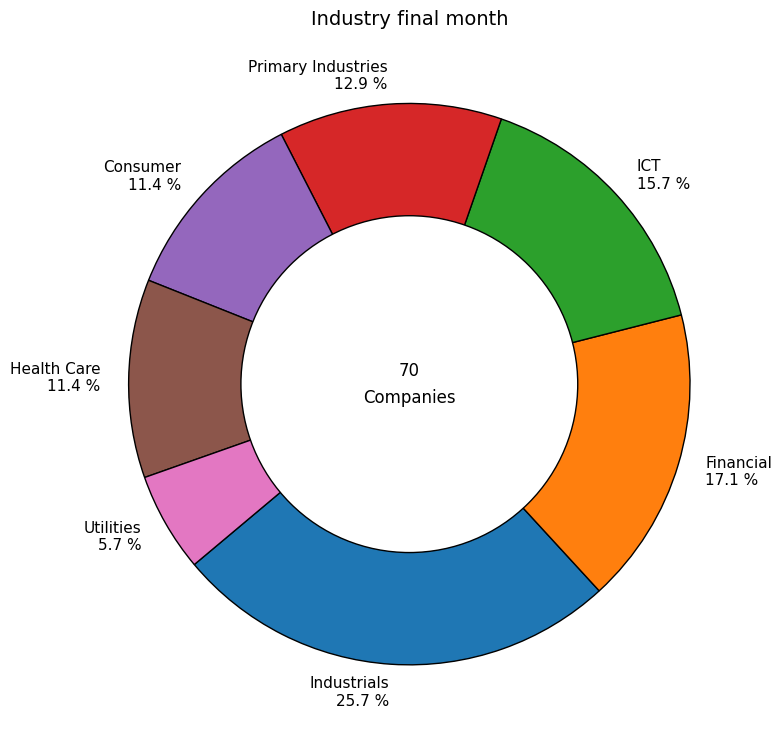

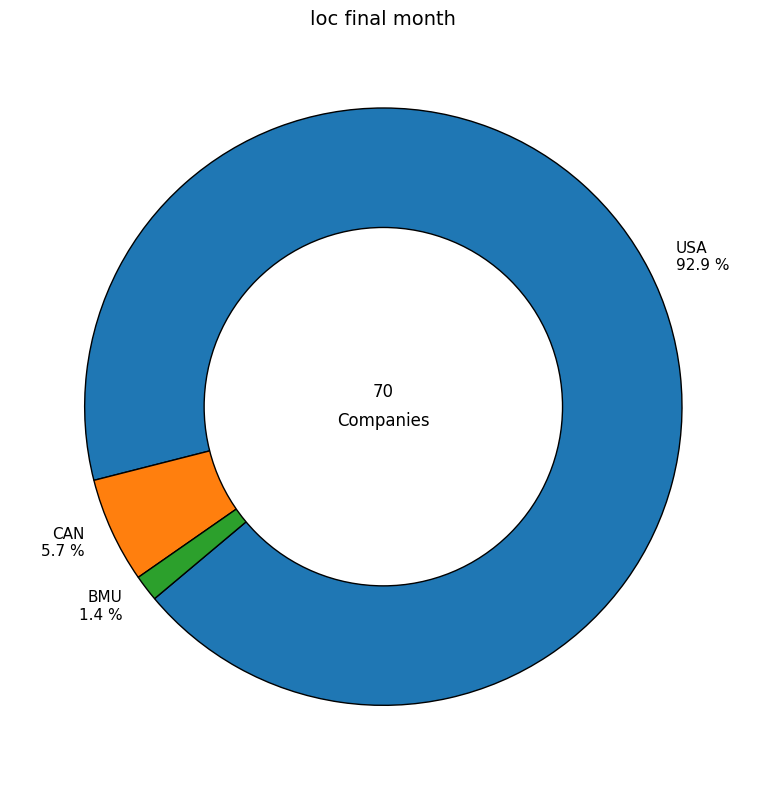

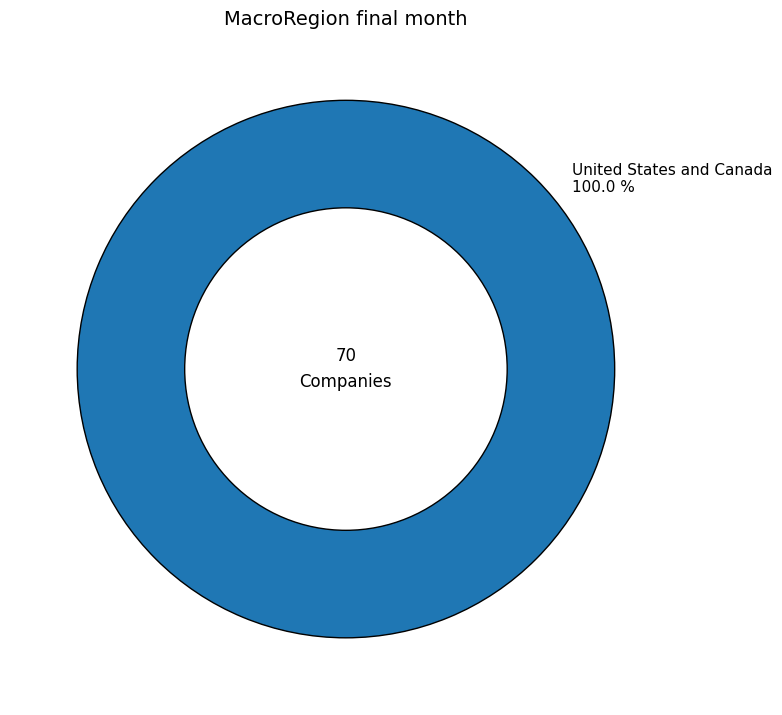

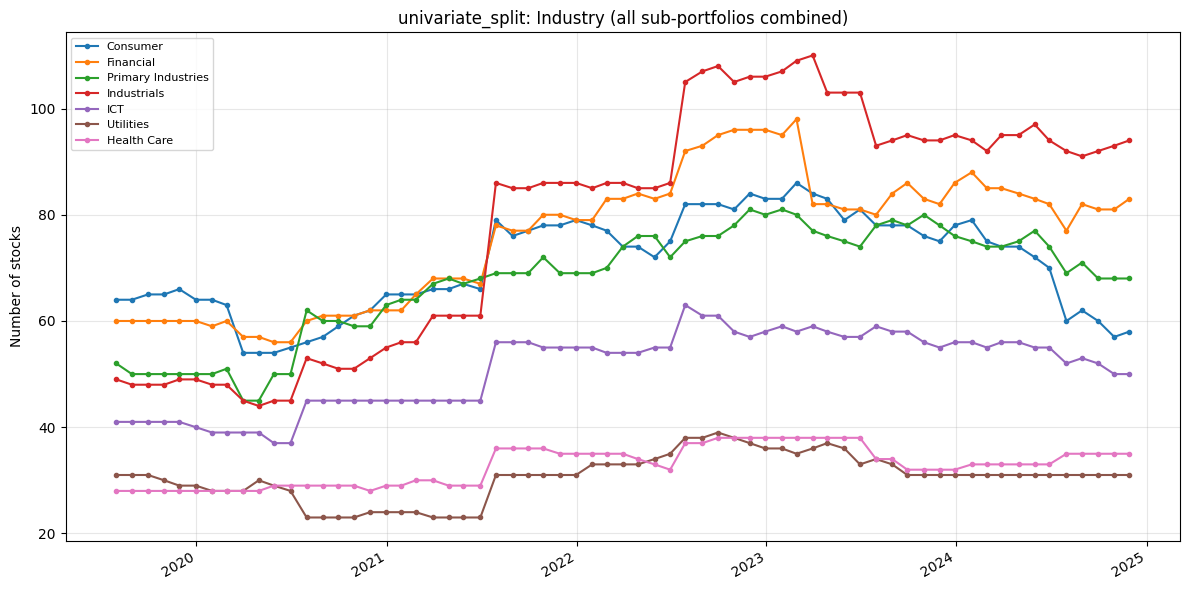

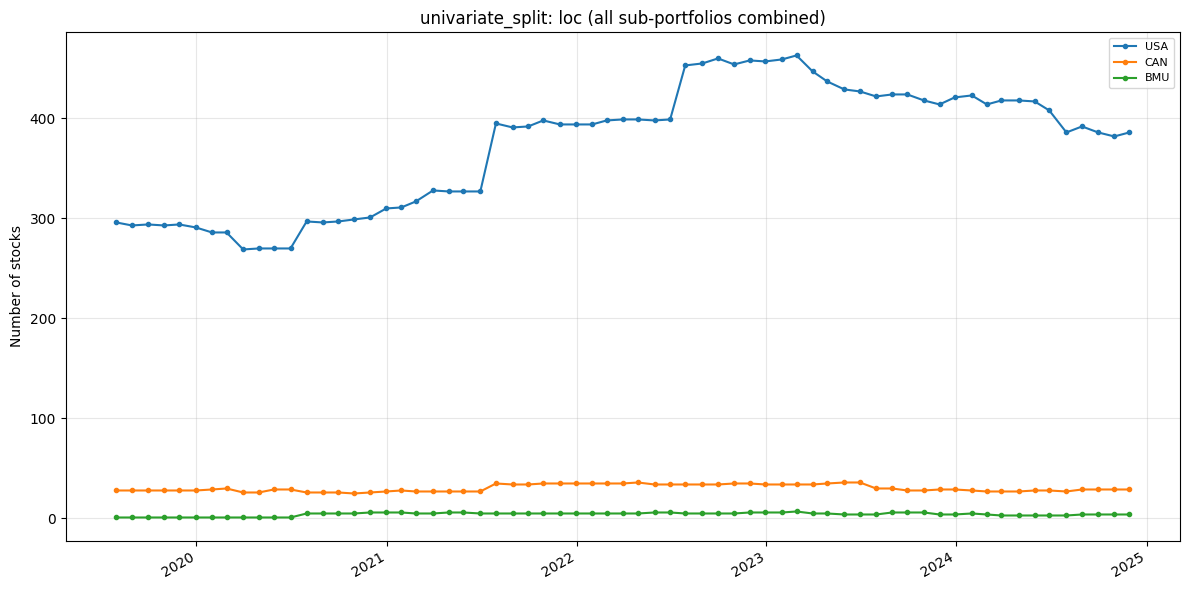

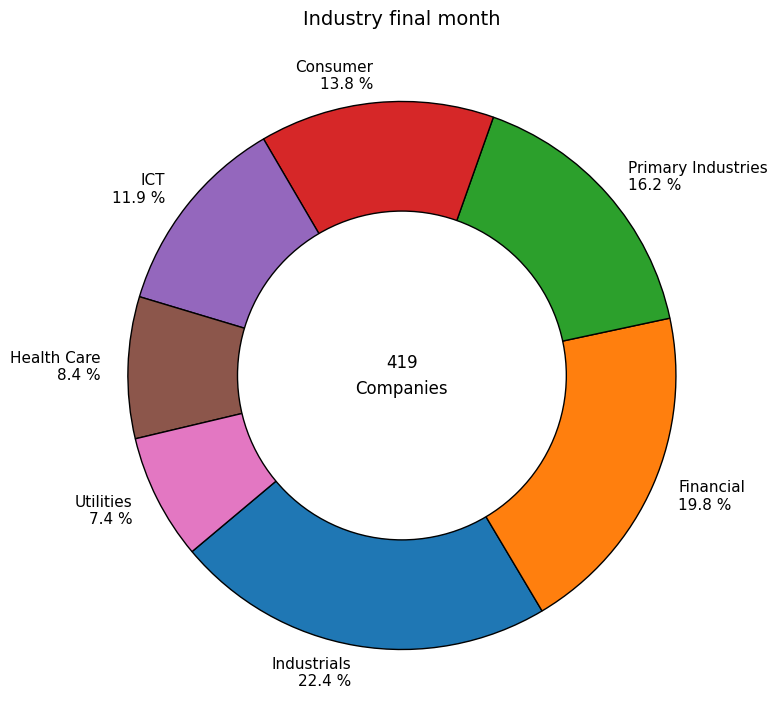

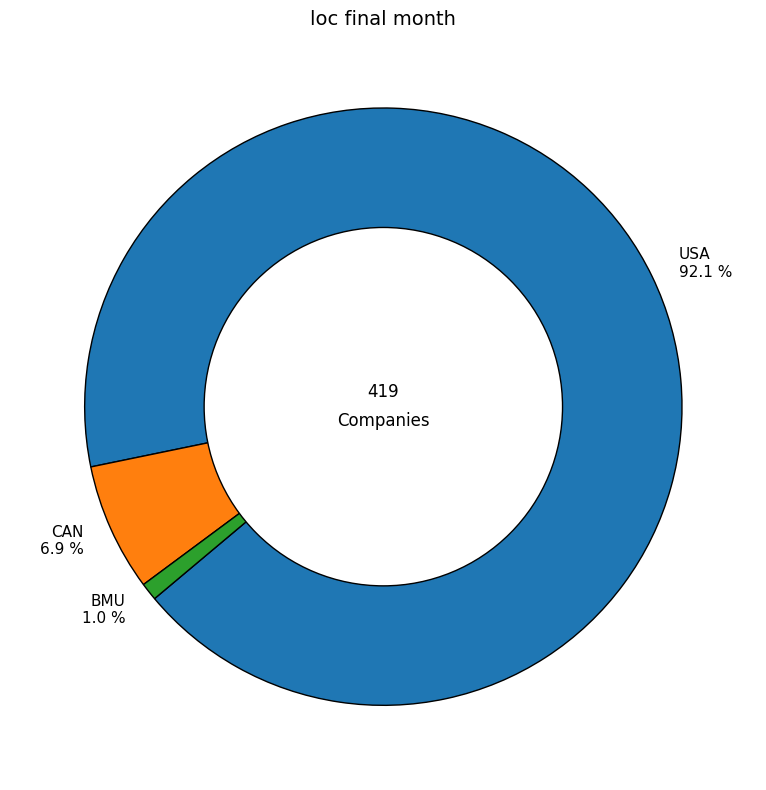

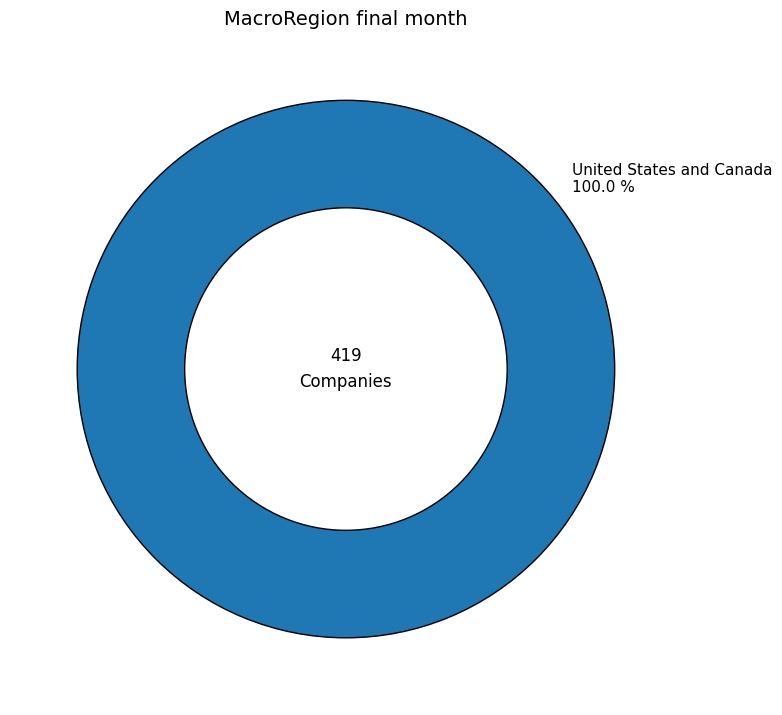

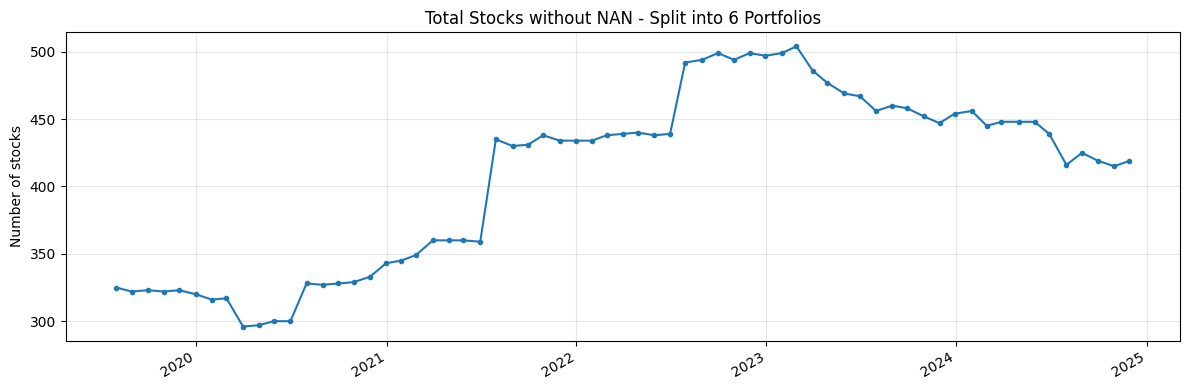

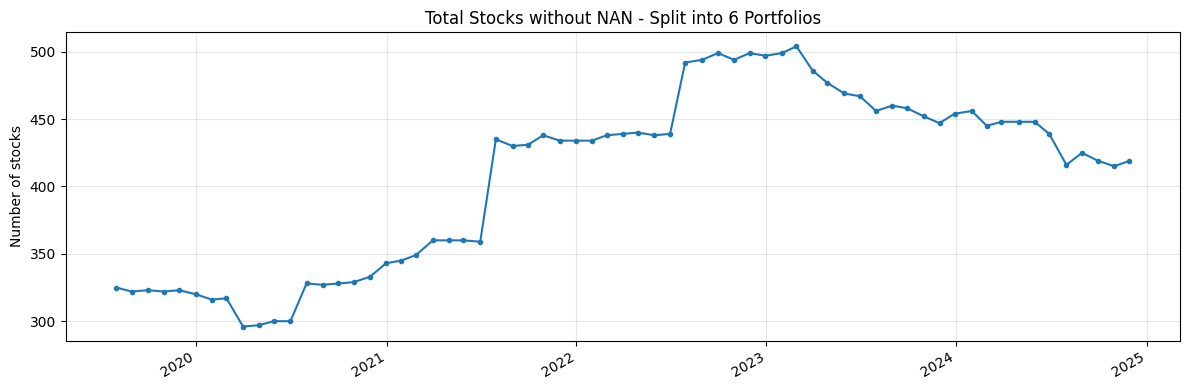

In [503]:
from IPython.display import display
from functions.portfolio_metrics.Portfolio_Constituents import PortfolioConstituents
import importlib
import functions.output_paths as output_paths_module
importlib.reload(output_paths_module)
from functions.output_paths import output_images_other_dir

# Portfolio constituents inspection: pinned to signal_2 normally; to the chosen ESG
# signal when esg_full_universe (signal_2 does not exist in that mode).
if esg_full_universe:
    _constituents_key = next(iter(universe_signals))   # the single esg_<provider> column
else:
    _constituents_key = "signal_2"
signal_2_simple_quantiles_constituents = signal_quantile_constituents[_constituents_key]

if "start_date" not in globals() or "end_date" not in globals():
    _pc_dates = pd.to_datetime(signal_2_simple_quantiles_constituents.index)
    start_date = str(_pc_dates.min())[:7]
    end_date = str(_pc_dates.max())[:7]

_constituents_img_dir = output_images_other_dir(
    action_characterization, region_analysis, signal_denominator, start_date, end_date, no_simple_quantiles,
    esg_choice=esg_choice,
    execute_3_filters=execute_3_filters,
)

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)

# esg_full_universe has no LC-derived `loc`/`MacroRegion`, so only break down by Industry.
_pc_cat_cols = ["Industry"] if esg_full_universe else ["Industry", "loc"]
_pc_pie_cols = ["Industry"] if esg_full_universe else ["Industry", "loc", "MacroRegion"]




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(category_over_time_cols=_pc_cat_cols, pie_cols=_pc_pie_cols,
                  save=True, show=True, out_dir=str(_constituents_img_dir))

# Options:
pc2.run_all_plots(
    category_over_time_cols=_pc_cat_cols, pie_cols=_pc_pie_cols,
    analyse_all_portfolios_at_once=True, save=True, show=True, out_dir=str(_constituents_img_dir)
)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")


In [504]:
# --- ESG portfolio holdings over time (what's IN the bucket each month) -------
# Simple knob: which quantile bucket to inspect.
#   0 = lowest-signal bucket ... (no_simple_quantiles - 1) = highest = "High ESG"
inspect_portfolio_key = no_simple_quantiles - 1   # <-- change to inspect a different bucket

_rows = []
for _ms in pc2.constituents:                      # one Series per formation month
    _names = _ms.iloc[inspect_portfolio_key]      # gvkey_iid list in that bucket that month
    for _gi in list(_names):
        _rows.append({
            "date": pd.to_datetime(_ms.name),
            "gvkey_iid": str(_gi),
            "gvkey": str(_gi).split("_")[0],
        })

holdings_over_time = (
    pd.DataFrame(_rows)
    .sort_values(["date", "gvkey_iid"])
    .reset_index(drop=True)
)

print(
    f"Bucket {inspect_portfolio_key} (0=low .. {no_simple_quantiles - 1}=high) | "
    f"{holdings_over_time['date'].nunique()} months | "
    f"{holdings_over_time['gvkey'].nunique()} unique firms"
)
display(holdings_over_time)

# Wide date x firm membership matrix (1 = in the bucket that month), if you want it:
# holdings_matrix = (holdings_over_time.assign(_in=1)
#                    .pivot_table(index="date", columns="gvkey", values="_in", fill_value=0))


Bucket 5 (0=low .. 5=high) | 65 months | 292 unique firms


,date,gvkey_iid,gvkey
0,2019-07-31,001075_1,001075
1,2019-07-31,001300_1,001300
2,2019-07-31,001487_1,001487
3,2019-07-31,001690_1,001690
4,2019-07-31,002136_1,002136
...,...,...,...
4395,2024-11-29,176701_1,176701
4396,2024-11-29,177088_1,177088
4397,2024-11-29,178803_1,178803
4398,2024-11-29,179741_1,179741


In [505]:
# --- Parameter summary (prints below the cell) ---
from functions.output_paths import RUN_PARAM_NAMES, format_run_parameters

_run_parameters_text = format_run_parameters(globals(), RUN_PARAM_NAMES)
print(_run_parameters_text)


=== Run parameters ===
golden_data                  = 'v_2C'
region_analysis              = 'North_America_and_Canada'
action_characterization      = 'original_matteo'
signal_denominator           = 'Sum_All_Signals'
start_year                   = 2018
end_year                     = 2024
no_simple_quantiles          = 6
ff_factors_number            = 3
fama_factor_region           = 'North_America_and_Canada'
fama_factors_currency        = 'JPY'
RF_JAPAN_PATH                = './data/FAMA/Rf_Japan_Monthly.xlsx'
currency_filter              = ['USD']
convert_to_USD               = False
region_filter                = ['United States and Canada']
execute_region_filters       = True
esg_choice                   = 'none'
msci_score_column            = 'weighted'
esg_full_universe            = False
download_gics_data           = False
esg_min_group_size           = 5
drop_real_estate_Full_ESG    = True
drop_utilities_Full_ESG      = True
show_esg_corr_matricies      = False
esg_corr_metho

In [506]:
# --- Sample coverage diagnostic (isolated in functions/extra_functions/plot_coverage.py) ---
# Plots, over time, how much of the INVESTABLE UNIVERSE our analysis SAMPLE covers:
#   * market-cap coverage (computed in the run's analysis currency; never mixes currencies)
#   * name coverage
# plus a count subplot (sample stocks / names) directly comparable to the
# "Total Stocks without NAN" plot.
#
# EXACT sample: we pass `global_returns` -- the masked date x gvkey_iid analysis panel
# (post LC-intersection, standardization dropna, and cross-signal NaN mask). A listing
# counts in a month iff its cell is non-NaN that month, so the curves and the count
# subplot track the real sample to the listing. Reads already-computed objects only.

if plot_coverage:   
    import importlib
    import functions.extra_functions.plot_coverage as _plot_coverage_module
    importlib.reload(_plot_coverage_module)
    from functions.extra_functions.plot_coverage import plot_universe_coverage_from_regions

    _coverage_save = (_other_img_dir / "sample_coverage_over_time.png") if "_other_img_dir" in globals() else None



    coverage_over_time = plot_universe_coverage_from_regions(
        usa_universe,
        row_universe,
        japan_universe,
        global_returns,             # masked analysis panel (exact non-NaN sample that entered the sorts)
        currency_filter=currency_filter,
        mktcap_covered=mktcap_covered,
        esg_choice=esg_choice,
        convert_to_USD=convert_to_USD,
        region_analysis=region_analysis,
        save_path=_coverage_save,
    )

    display(
        coverage_over_time[
            ["issues_sample", "names_sample", "names_total",
            "mktcap_coverage_pct", "name_coverage_pct"]
        ].describe().round(1)
    )

In [ ]:
# --- ESG coverage diagnostic (gated by show_esg_coverage; skipped under sweep_mode) ---
# % of firm-years with a non-NaN ESG score, per provider, for two samples:
#   row 1 = raw-LC signal-active firm-years (loc == 'JPN'), BEFORE sample filters
#   row 2 = post-filter stock-fiscal-years actually traded in global_returns
# Note: S&P attaches as-of the trading date (merge_asof); MSCI/Refinitiv attach by
# fiscal year (last_year) -- directionally comparable, not identical temporal footing.
#
# The pipeline only merges the ONE provider chosen by esg_choice, so we build a
# diagnostic-only copy of the universes carrying ALL THREE provider columns via
# merge_all_esg_to_universe (this does not touch the universes used by the pipeline).




# Note ESG is matched on "Last_Year" using the year_split_month
if show_esg_coverage and not globals().get("sweep_mode", False):
    from functions.data_functions.get_data import merge_all_esg_to_universe
    _usa_cov, _row_cov, _jpn_cov = merge_all_esg_to_universe(
        usa_universe, row_universe, japan_universe, msci_score_column=msci_score_column
    )
    esg_lookup = build_esg_lookup(_usa_cov, _row_cov, _jpn_cov)
    cov1 = coverage_sample1_lc(lc_raw_for_coverage, esg_lookup, categories_dict, signal_denominator)
    cov2 = coverage_sample2_returns(global_returns, prep.global_universe, esg_lookup)
    esg_coverage_table_df = esg_coverage_table(cov1, cov2)
    display(esg_coverage_table_df)

    # Number of region firms each provider has ESG data for, per fiscal year
    firms_with_esg_data_df = firms_with_esg_data_by_year(japan_universe, msci_score_column=msci_score_column)
    print("Number of firms with ESG data")
    display(firms_with_esg_data_df)
